# Data Cleaning — 
**Proyecto:** Simulació Empresarial IT Academy — Bank Marketing

**Variables asignadas, Andrey:** `age`, `job`, `marital`, `education`, `default`, `balance`, `housing`, `loan`, `contact` 

**Variables asignadas, Margot:** `day`, `month`, `duration`, `campaign`, `pdays`, `previous`, `poutcome`, `deposit` 

**Áreas cubiertas:** 1-Nulos · 2-Duplicados · 3-Outliers · 4-Estandarización · 5-Tipos de dato  

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Lectura del archivo

In [114]:
fichero = 'df_original_260420.csv'
df = pd.read_csv(fichero)

In [115]:
if 'id' in df.columns: df.set_index('id', inplace=True)
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
id,,,,,,,,,,,,,,,,,
1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [116]:
print(f'Dataset cuenta {df.shape[0]} regisrtos y {df.shape[1]} variables')

Dataset cuenta 10642 regisrtos y 17 variables


## Variables, valores unicos, tipo, ejemplos de valores

In [117]:
variables = pd.DataFrame(columns=['Variable', 'Número de valores unicos', 'Tipo','Valores'])
for i, var in enumerate(df.columns):
    variables.loc[i] = [var, df[var].nunique(), df[var].dtype,df[var].unique().tolist()]

variables

,Variable,Número de valores unicos,Tipo,Valores
0,age,76,float64,"[59.0, 56.0, 41.0, 55.0, 54.0, 42.0, 60.0, 37...."
1,job,12,object,"[admin., technician, services, management, ret..."
2,marital,3,object,"[married, single, divorced, nan]"
3,education,4,object,"[secondary, tertiary, primary, unknown, nan]"
4,default,2,object,"[no, yes]"
5,balance,3703,int64,"[2343, 45, 1270, 2476, 184, 0, 830, 545, 1, 50..."
6,housing,2,object,"[yes, no]"
7,loan,2,object,"[no, yes]"
8,contact,3,object,"[unknown, cellular, telephone]"
9,day,31,int64,"[5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 19, 20, 21..."


## Revisión de valores nulos

In [118]:
# Valores nulos por variable
nulos = df.isnull().sum()

# Calcular el porcentaje de nulos
nulos_porcentaje = (nulos / len(df)) * 100

null_info = pd.DataFrame({
    'Variable': nulos.index,
    'Nulos': nulos.values,
    'Porcentaje de Nulos': nulos_porcentaje.values
})

null_info

,Variable,Nulos,Porcentaje de Nulos
0,age,9,0.084571
1,job,0,0.000000
2,marital,5,0.046984
3,education,7,0.065777
4,default,0,0.000000
5,balance,0,0.000000
6,housing,0,0.000000
7,loan,0,0.000000
8,contact,0,0.000000
9,day,0,0.000000


Variables **age**, **marital**, **education** presentan valores nulos.
- **age** : 9 (0.08%)
- **marital** : 5 (0.05%)
- **education**: 7 (0.07%)

Filas con valores nulos

In [119]:
df_nulos = df[df.isna().any(axis=1)]
print(df_nulos.shape)
df_nulos

(21, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
id,,,,,,,,,,,,,,,,,
1089,53.0,management,NaN,secondary,no,1004,no,yes,telephone,22,dec,119,1,-1,0,unknown,yes
1182,NaN,management,married,tertiary,no,309,yes,no,cellular,5,feb,676,1,-1,0,unknown,yes
1301,37.0,technician,married,NaN,no,549,no,no,cellular,2,mar,239,1,-1,0,unknown,yes
1411,NaN,blue-collar,married,primary,no,4979,no,no,telephone,6,apr,180,1,-1,0,unknown,yes
2944,24.0,student,single,NaN,no,382,no,no,cellular,13,nov,256,2,92,3,failure,yes
3720,68.0,retired,NaN,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
4020,NaN,services,single,secondary,no,1934,no,no,cellular,29,sep,271,1,-1,0,unknown,yes
4738,37.0,management,single,NaN,no,102,yes,no,cellular,6,may,445,1,258,2,failure,yes
4855,34.0,management,NaN,tertiary,no,5,no,no,cellular,18,aug,370,2,-1,0,unknown,yes


## Imputación de nulos

##### Variable **age**: reemplazamos valores nulos por la mediana de **age** de grupos agrupados por las variables **education**,**marital**,**job**

In [120]:
mask_age = df[['education','marital']].notna().all(axis=1)

df.loc[mask_age, 'age'] = (
    df.loc[mask_age]
      .groupby(['education','marital','job'])['age']
      .transform(lambda x: x.fillna(x.median()))
)

#### Usar **age** exacta genera grupos pequeños por eso he dividido los valores por grupos

In [121]:
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 120], include_lowest=True)

##### Variable **marital**: reemplazamos valores nulos por la moda de **marital** de grupos agrupados por las variables **age_group**, **education**, **job**

In [122]:
mask_marital = df[['education']].notna().all(axis=1)

df.loc[mask_marital,'marital'] = (
    df.loc[mask_marital]
    .groupby(['age_group','education','job'])['marital']
    .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan))
)


##### Variable **education**: reemplazamos valores nulos por la moda de **education** de grupos agrupados por las variables **age_group**, **marital**, **job**

In [123]:
df['education'] = (
    df.groupby(['age_group','marital','job'])['education']
    .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan))
)

#### Comprobamos que no hay valores nulos

In [124]:
df[['age', 'marital', 'education']].isnull().sum()

age          0
marital      0
education    0
dtype: int64

In [125]:
if 'age_group' in df.columns: df.drop(columns='age_group', inplace=True)

### Variable **age**

In [126]:
df['age'].describe()

count    10642.000000
mean        41.250000
std         11.999135
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64

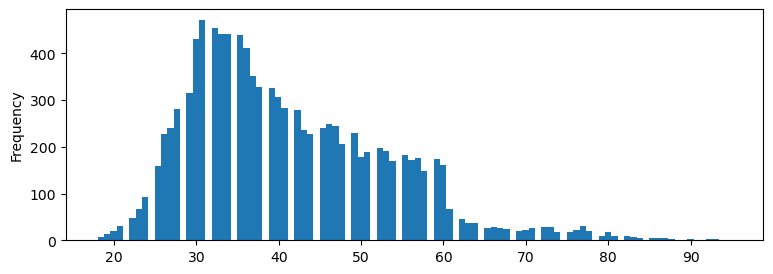

In [127]:
df['age'].plot.hist(bins=100, figsize=(9,3));

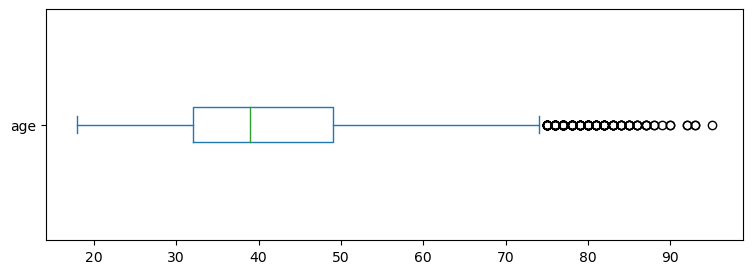

In [128]:
df['age'].plot.box(figsize=(9,3), vert=False);

Datos estan concentados en el rango 25 -60 años. Varible age presenta valores atipicos.

### Variable **job**

In [129]:
df['job'].value_counts()

job
management       2447
blue-collar      1830
technician       1737
admin.           1279
services          881
retired           755
self-employed     388
student           354
unemployed        338
entrepreneur      308
housemaid         257
unknown            68
Name: count, dtype: int64

##### Cambia el tipo por string

In [130]:
df['job'] = df['job'].astype('string')

##### Reemplazamos **admin.** por **administration**

In [131]:
df['job'] = df['job'].replace('admin.', 'administration')

### Variable **marital**

In [132]:
df['marital'].value_counts()

marital
married     6034
single      3375
divorced    1233
Name: count, dtype: int64

##### Cambia el tipo por string

In [133]:
df['marital'] = df['marital'].astype('string')

### Variable **education**

In [134]:
df['education'].value_counts()

education
secondary    5221
tertiary     3529
primary      1419
unknown       473
Name: count, dtype: int64

##### Cambia el tipo por string

In [135]:
df['education'] = df['education'].astype('string')

### Variable **default**

In [136]:
df['default'].value_counts()

default
no     10487
yes      155
Name: count, dtype: int64

##### Cambia el tipo por string

In [137]:
df['default'] = df['default'].astype('string')

### Variable **balance**

In [138]:
df['balance'].describe()

count    10642.000000
mean      1536.614828
std       3223.419300
min      -6847.000000
25%        127.000000
50%        558.000000
75%       1728.750000
max      81204.000000
Name: balance, dtype: float64

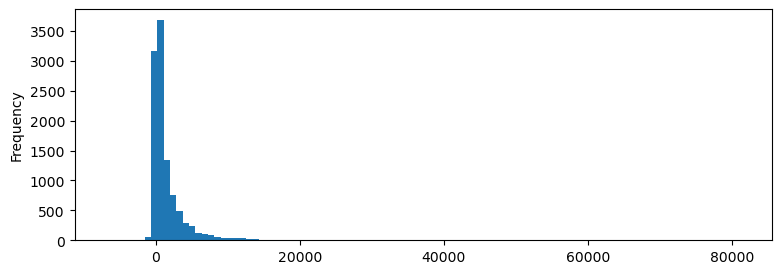

In [139]:
df['balance'].plot.hist(bins=100, figsize=(9,3));

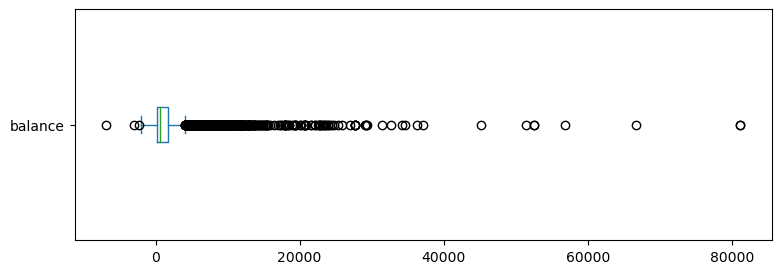

In [140]:
df['balance'].plot.box(figsize=(9,3), vert=False);

### Variable **housing** 

In [141]:
df['housing'].value_counts()

housing
no     5660
yes    4982
Name: count, dtype: int64

##### Cambia el tipo por string

In [142]:
df['housing'] = df['housing'].astype('string')

### Variable **loan**

In [143]:
df['loan'].value_counts()

loan
no     9270
yes    1372
Name: count, dtype: int64

##### Cambia el tipo por string

In [144]:
df['loan'] = df['loan'].astype('string')

### Variable **contact** 

In [145]:
df['contact'].value_counts()

contact
cellular     7707
unknown      2196
telephone     739
Name: count, dtype: int64

##### Cambia el tipo por string

In [146]:
df['contact'] = df['contact'].astype('string')

### Variable **poutcome** 

In [147]:
df['poutcome'].value_counts()

poutcome
unknown    7885
failure    1180
success    1065
other       512
Name: count, dtype: int64

##### Cambia el tipo por string

In [148]:
df['poutcome'] = df['poutcome'].astype('string')

### Variable **deposit** 

In [149]:
df['deposit'].value_counts()

deposit
no     5353
yes    5289
Name: count, dtype: int64

##### Cambia el tipo por string

In [150]:
df['deposit'] = df['deposit'].astype('string')

## Selección de variables
Se trabaja directamente sobre `df`. Se seleccionan las 8 variables asignadas.

In [151]:
# df = pd.read_csv('df_original_260420.csv')

variables_fin = ['day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']
# df[['id'] + variables_fin].head()
df[variables_fin].head()

,day,month,duration,campaign,pdays,previous,poutcome,deposit
id,,,,,,,,
1,5,may,1042,1,-1,0,unknown,yes
2,5,may,1467,1,-1,0,unknown,yes
3,5,may,1389,1,-1,0,unknown,yes
4,5,may,579,1,-1,0,unknown,yes
5,5,may,673,2,-1,0,unknown,yes


## Diagnóstico inicial
Vista general antes de cualquier transformación: nulos, unknowns, estadísticas y duplicados.

In [152]:
# subset = df[['id'] + variables_fin]
subset = df[variables_fin]

# Nulos reales
print("Nulos por columna:")
print(subset.isnull().sum())

Nulos por columna:
day         0
month       0
duration    0
campaign    0
pdays       0
previous    0
poutcome    0
deposit     0
dtype: int64


In [153]:
# Unknowns en categóricas
print("\nUNKNOWNS en categóricas:")
for col in ['poutcome']:
    n = (subset[col] == 'unknown').sum()
    print(f"  {col}: {n} ({n/len(subset)*100:.1f}%)")


UNKNOWNS en categóricas:
  poutcome: 7885 (74.1%)


In [154]:
# Estadísticas numéricas
print("\nEstadísticas numéricas:")
subset[['day','duration','campaign','pdays','previous']].describe().round(2)


Estadísticas numéricas:


,day,duration,campaign,pdays,previous
count,10642.00,10642.00,10642.00,10642.00,10642.00
mean,15.65,378.69,2.50,52.07,0.85
std,8.43,351.18,2.69,109.21,2.32
min,1.00,2.00,1.00,-1.00,0.00
25%,8.00,141.00,1.00,-1.00,0.00
50%,15.00,260.00,2.00,-1.00,0.00
75%,22.00,510.00,3.00,57.75,1.00
max,31.00,3881.00,63.00,854.00,58.00


## Área 1 — Tratamiento de valores nulos (NaN)

In [155]:
assert df[variables_fin].isnull().sum().sum() == 0, "Se encontraron NaN inesperados"
print("✓ Área 1 — Sin NaN en las variables asignadas. No se requiere acción.")

✓ Área 1 — Sin NaN en las variables asignadas. No se requiere acción.


## Área 2 — Duplicados

In [156]:
n_dup = df.duplicated().sum()
n_dup_id = df.index.duplicated().sum()
print(f"Filas duplicadas: {n_dup} | IDs duplicados: {n_dup_id}")

if n_dup > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"  → Eliminadas. Filas restantes: {len(df)}")
else:
    print("✓ Área 2 — Sin duplicados. No se requiere acción.")

Filas duplicadas: 0 | IDs duplicados: 0
✓ Área 2 — Sin duplicados. No se requiere acción.


## Área 2 — Valores atípicos (Outliers)

### Variables numéricas: `duration`, `campaign`, `previous`
**Método:** IQR para detección. 
**Sugerencia:** No se eliminan filas podria usarse tecnicas como la Winsorizacion. Es preferible a la eliminación cuando la proporción de outliers > 5%.

### Variable especial: `pdays`
**Diagnóstico:** `pdays = -1` es una **codificación de negocio** (cliente no contactado previamente), no un outlier.  
Se separa en:
- `pdays = -1` → `NaN` (para análisis estadístico correcto de días entre contactos)
- Nueva variable binaria `contactado_campania_previa` (0/1)  
**Justificación:** Tratar -1 como valor numérico contaminaría media y desviación estándar de `pdays`.

In [157]:
# --- Winsorizing P99 para duration, campaign, previous ---
for col in ['duration', 'campaign', 'previous']:
    p99 = df[col].quantile(0.99)
    antes = df[col].max()
    df[col] = df[col].clip(upper=p99)
    print(f"{col}: max antes={antes:.0f} → cap P99={p99:.0f}")

duration: max antes=3881 → cap P99=1590
campaign: max antes=63 → cap P99=13
previous: max antes=58 → cap P99=10


In [158]:
# --- Tratamiento de pdays = -1 ---
df['contactado_campania_previa'] = (df['pdays'] != -1).astype(int)
df['pdays'] = df['pdays'].replace(-1, np.nan)

In [159]:
print(f"\npdays: {(df['pdays'].isna()).sum()} NaN (no contactados previamente)")
print(f"contactado_campania_previa: {df['contactado_campania_previa'].value_counts().to_dict()}")


pdays: 7883 NaN (no contactados previamente)
contactado_campania_previa: {0: 7883, 1: 2759}


## Área 3 — Estandarización de formatos

### `month` → Categorical ordenado
**Decisión:** Convertir a `pd.Categorical` con orden cronológico natural.  
**Justificación:** `month` es una variable **ordinal** (tiene orden lógico: ene < feb < ... < dic). 
Las buenas prácticas indican que variables ordinales no deben tratarse como nominales ni reordenarse por frecuencia.

### `poutcome` → Renombrar `unknown` a `sin_campania_previa`
**Decisión:** No convertir a NaN. El `unknown` tiene significado de negocio documentado.  
**Justificación:** El 74.1% de `poutcome='unknown'` coincide con `pdays=-1` (cliente sin campaña previa). 
Convertirlo a NaN e imputarlo generaría información falsa. Es una categoría válida.

### `deposit` → Estandarizar strings
**Decisión:** Strip + lowercase para asegurar consistencia.

### `day` → Verificar rango válido
**Decisión:** Solo verificación (rango 1-31). No requiere transformación.

In [160]:
# month → Categorical ordenadocon orden cronológico natural
orden_meses = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(
    df['month'].str.strip().str.lower(),
    categories=orden_meses,
    ordered=True
)

In [161]:
# poutcome → renombrar unknown (significado de negocio)
df['poutcome'] = df['poutcome'].str.strip().str.lower().replace('unknown', 'sin_campania_previa')

In [162]:
# deposit → estandarizar string
df['deposit'] = df['deposit'].str.strip().str.lower()

In [163]:
# day → verificación de rango
assert df['day'].between(1, 31).all(), "Valores de day fuera de rango válido"

In [164]:
print("Distribución month:", df['month'].value_counts().sort_index().to_dict())
print("\nDistribución poutcome:", df['poutcome'].value_counts().to_dict())
print("\nDistribución deposit:", df['deposit'].value_counts().to_dict())
print("\n✓ Área 4 — Estandarización completa.")

Distribución month: {'jan': 327, 'feb': 746, 'mar': 274, 'apr': 888, 'may': 2646, 'jun': 1174, 'jul': 1429, 'aug': 1450, 'sep': 314, 'oct': 387, 'nov': 898, 'dec': 109}

Distribución poutcome: {'sin_campania_previa': 7885, 'failure': 1180, 'success': 1065, 'other': 512}

Distribución deposit: {'no': 5353, 'yes': 5289}

✓ Área 4 — Estandarización completa.


## Área 5 — Corrección de tipos de dato

Según la documentación oficial del dataset UCI Bank Marketing, solo se modifico `month`, `pdays` 
`pdays` pasó de `int64` a `float64` por efecto de `np.nan`. 

In [165]:
print("Tipos de dato post-limpieza:")
cols_check = variables_fin + ['contactado_campania_previa']
print(df[cols_check].dtypes)

# Asserts de tipos esperados
assert df['day'].dtype == 'int64'
assert df['duration'].dtype in ['int64', 'float64']
assert df['campaign'].dtype in ['int64', 'float64']
assert df['previous'].dtype in ['int64', 'float64']
assert str(df['month'].dtype) == 'category'
assert df['pdays'].dtype == 'float64'
assert df['deposit'].dtype == 'string'
assert df['poutcome'].dtype == 'string'

print("\n✓ Área 5 — Tipos de dato son corregidos - fase de limpieza.")

Tipos de dato post-limpieza:
day                                    int64
month                               category
duration                             float64
campaign                               int64
pdays                                float64
previous                               int64
poutcome                      string[python]
deposit                       string[python]
contactado_campania_previa             int32
dtype: object

✓ Área 5 — Tipos de dato son corregidos - fase de limpieza.


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10642 entries, 1 to 10642
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   age                         10642 non-null  float64 
 1   job                         10642 non-null  string  
 2   marital                     10642 non-null  string  
 3   education                   10642 non-null  string  
 4   default                     10642 non-null  string  
 5   balance                     10642 non-null  int64   
 6   housing                     10642 non-null  string  
 7   loan                        10642 non-null  string  
 8   contact                     10642 non-null  string  
 9   day                         10642 non-null  int64   
 10  month                       10642 non-null  category
 11  duration                    10642 non-null  float64 
 12  campaign                    10642 non-null  int64   
 13  pdays                

In [167]:
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa
id,,,,,,,,,,,,,,,,,,
1,59.0,administration,married,secondary,no,2343,yes,no,unknown,5,may,1042.0,1,NaN,0,sin_campania_previa,yes,0
2,56.0,administration,married,secondary,no,45,no,no,unknown,5,may,1467.0,1,NaN,0,sin_campania_previa,yes,0
3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389.0,1,NaN,0,sin_campania_previa,yes,0
4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579.0,1,NaN,0,sin_campania_previa,yes,0
5,54.0,administration,married,tertiary,no,184,no,no,unknown,5,may,673.0,2,NaN,0,sin_campania_previa,yes,0
6,42.0,management,single,tertiary,no,0,yes,yes,unknown,5,may,562.0,2,NaN,0,sin_campania_previa,yes,0
7,56.0,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201.0,1,NaN,0,sin_campania_previa,yes,0
8,60.0,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030.0,1,NaN,0,sin_campania_previa,yes,0
9,37.0,technician,married,secondary,no,1,yes,no,unknown,6,may,608.0,1,NaN,0,sin_campania_previa,yes,0


In [168]:
df.to_parquet('df_limpiado.parquet')